1. Lineer Regresyon (Linear Regression)

    Nedir? Veriler arasına en uygun düz çizgiyi çekme sanatıdır.

    Ne Zaman Kullanılır? Tahmin etmek istediğin şey sürekli bir sayıysa (fiyat, hız, açı).

    Nasıl? Giriş verileri ile çıkış arasında doğrusal bir ilişki kurar (y=ax+b).

    Niye? Çok hızlıdır ve işlemciyi yormaz.

    Otonom Örnek: Şeridin eğimine bakarak direksiyonun kaç derece çevrileceğini hesaplamak.

2. Lojistik Regresyon (Logistic Regression)

    Nedir? Adında "regresyon" geçse de aslında bir sınıflandırma algoritmasıdır.

    Ne Zaman Kullanılır? Sonuç "Evet mi Hayır mı?" (0 veya 1) gibi iki seçenekliyse.

    Nasıl? Verileri 0 ile 1 arasına sıkıştırarak bir olasılık değeri üretir.

    Niye? Basit, hızlı ve açıklanabilir olduğu için güvenlik kritik sistemlerde ilk tercihtir.

    Otonom Örnek: "Öndeki araçla mesafe kritik mi? (Güvenli: 1 / Tehlikeli: 0)".

3. Yapay Sinir Ağları (Neural Networks / Deep Learning)

    Nedir? Beyindeki nöronların çalışma mantığını taklit eden, katmanlı bir yapıdır.

    Ne Zaman Kullanılır? Veri çok karmaşıksa; özellikle görüntü, ses ve metin işleniyorsa.

    Nasıl? Katmanlar ilerledikçe piksellerden çizgiler, çizgilerden şekiller, şekillerden nesneler üretir.

    Niye? "Feature Engineering" (özellik çıkarma) işini kendi yapar, senin "şunun boyu şu kadar" demene gerek kalmaz.

    Otonom Örnek: Kameradan gelen görüntüde nesne tespiti yapmak ve Softmax ile bunun %90 ihtimalle "duba" olduğunu söylemek.

4. Random Forests (Rastgele Ormanlar)

    Nedir? Çok sayıda karar ağacının oylama yaparak karar verdiği bir "demokrasi" sistemidir.

    Ne Zaman Kullanılır? Elinde tablo verisi (Excel gibi) varsa ve modelin ezber yapmasını (overfitting) istemiyorsan.

    Nasıl? Hem veriyi hem de özellikleri rastgele seçerek birbirinden farklı yüzlerce ağaç eğitir.

    Niye? Çok dayanıklıdır; sensörlerin biri hatalı veri gönderse bile diğer ağaçlar bunu oylamayla düzeltir.

    Otonom Örnek: Lidar ve radar verilerini birleştirerek engelin tipine (duba vs. yaya) karar vermek.

5. XGBoost (Extreme Gradient Boosting)

    Nedir? Ağaçların birbirinin hatasını düzelterek sırayla eğitildiği, askeri disiplinli bir sistemdir.

    Ne Zaman Kullanılır? Hız ve milimetrik hassasiyet en büyük önceliğinse.

    Nasıl? Her yeni ağaç, bir öncekinin yaptığı hatayı (gradient) azaltmaya odaklanır.

    Niye? Dünyanın en performanslı tablo verisi algoritmasıdır, eksik verileri kendi yönetir.

    Otonom Örnek: Acil durumda tam durma mesafesini milimetrik olarak tahmin etmek.

Karar Verme Rehberin

    Görüntü İşleme mi yapıyorsun? -> Kesinlikle Neural Networks.

    Basit bir Evet/Hayır mı lazım? -> Logistic Regression.

    Sayısal bir değer mi tahmin ediyorsun? -> Linear Regression (basitse) veya XGBoost (hassassa).

    Tablo verisinde güvenilir bir sınıflandırma mı lazım? -> Random Forest.

XG BOOST

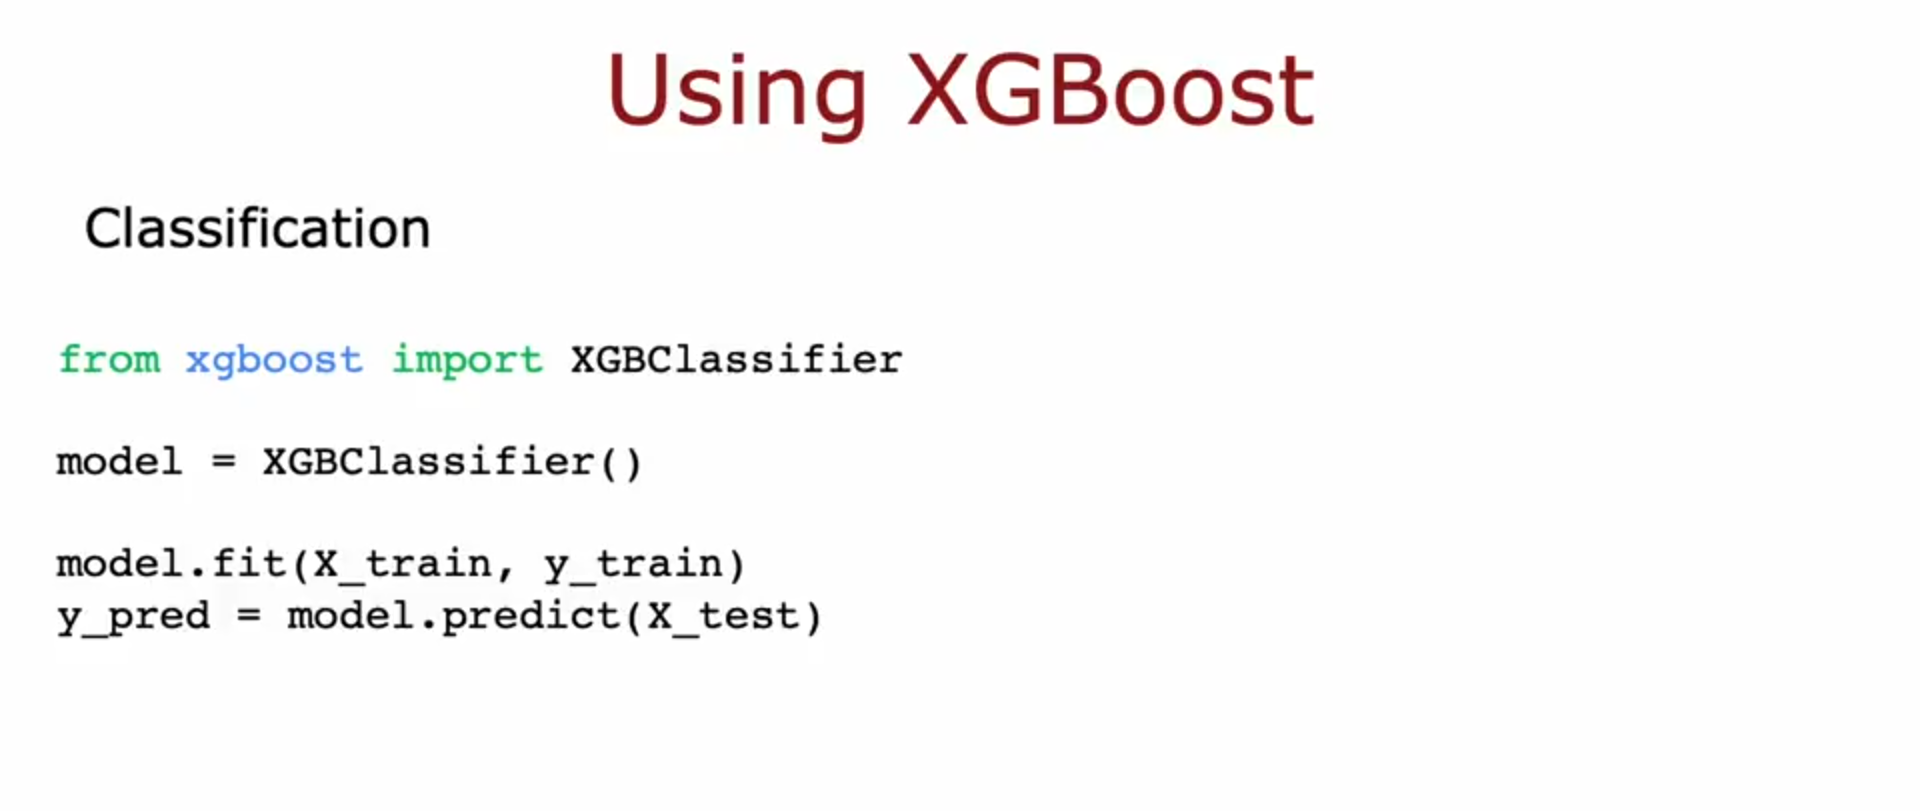

In [6]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Örnek Veri (Sensör Verileri: Mesafe, Hız, Yansıma)
X = np.array([[1.2, 20, 0.8], [5.0, 40, 0.2], [0.5, 10, 0.9], [10.0, 60, 0.1]])
y = np.array([1, 0, 1, 0]) # 1: Duba, 0: Engel Değil

# 2. Veriyi böl
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 3. XGBoost Modelini Tanımla
# objective='binary:logistic' -> Sınıflandırma yapacağımızı söyler
model = xgb.XGBClassifier(
    n_estimators=100,     # Kaç tane ağaç kurulsun
    learning_rate=0.1,    # Her ağacın hatayı düzeltme hızı (adım boyu)
    max_depth=3,          # Ağaçların derinliği (fazla olursa ezberler)
    use_label_encoder=False
)

# 4. Eğit (Fit)
model.fit(X_train, y_train)

# 5. Tahmin Yap
y_pred = model.predict(X_test)

# 6. Performansı Gör
print(f"Başarı Oranı: {accuracy_score(y_test, y_pred)}")

/home/enes/venv/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:40:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Başarı Oranı: 0.0
